# 가장 많이/적게(수량/금액) 팔린 제품
- 판매 table을 활용하여 수량 기준과 금액 기준으로 많이
팔린 제품과 적게 팔린 제품 분석.
- 실제 실무라면, 예상대로 판매가 이루어지고 있는지, 어떤
제품에 집중해야 하는지 등등 분석할 수 있음.

In [3]:
import mysql.connector
import pandas as pd
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

In [4]:
# MySQL 데이터베이스 연결 설정
conn = mysql.connector.connect(
    host='localhost',
    user='root',
    password='doruru0614!@#',        # 실제 비밀번호로 변경하세요
    database='classicmodels'
)


In [5]:
# 가장 잘 팔리는 제품 분석 쿼리 실행
# 각 제품의 총 판매량(total_quantity)를 계산하고, 가장 많이 팔린 제품을 상위 5개 출력
top_products_query = """
select p.productName,
       sum(od.quantityOrdered) as total_quantity
FROM products p
JOIN orderdetails od ON p.productCode = od.productCode
JOIN orders o ON od.orderNumber = o.orderNumber
where o.status = 'shipped'
group by p.productName
order by total_quantity desc
limit 5;
"""

In [6]:
# 가장 안 팔리는 제품 분석 쿼리 실행
bottom_products_query = """
select p.productName,
       sum(od.quantityOrdered) as total_quantity
FROM products p
JOIN orderdetails od ON p.productCode = od.productCode
JOIN orders o ON od.orderNumber = o.orderNumber
where o.status <> 'shipped'
group by p.productName
order by total_quantity asc
limit 5;

"""

In [7]:
# SQL 쿼리 실행 및 결과 DataFrame으로 변환
top_products_df = pd.read_sql_query(top_products_query, conn)
bottom_products_df = pd.read_sql_query(bottom_products_query, conn)

In [8]:
# 연결 종료
conn.close()

## 가장 많이 (수량) 팔린 제품

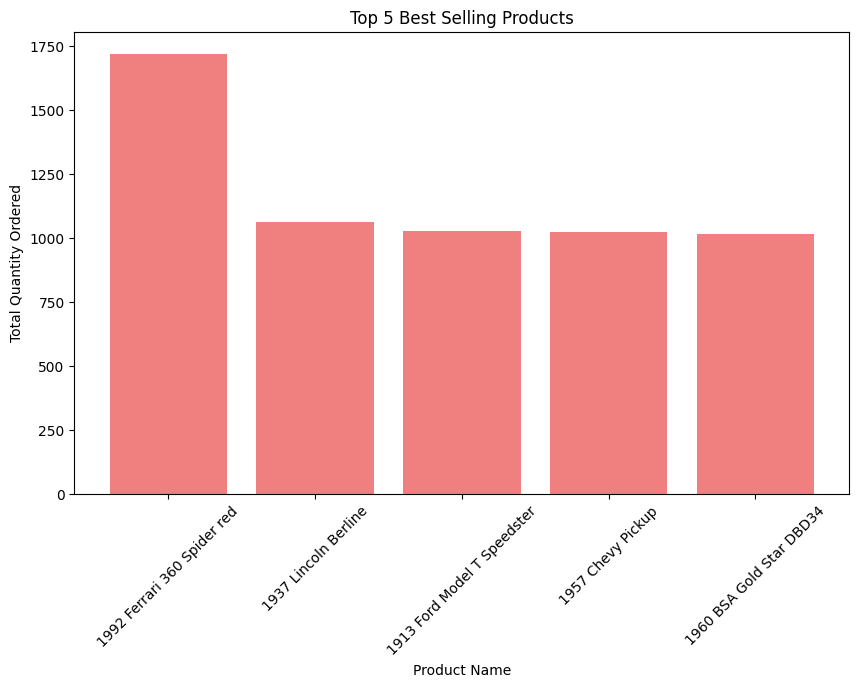

In [9]:
# 가장 잘 팔리는 제품 시각화
plt.figure(figsize=(10, 6))
plt.bar(top_products_df['productName'], top_products_df['total_quantity'], color='lightcoral')
plt.xlabel('Product Name')
plt.ylabel('Total Quantity Ordered')
plt.title('Top 5 Best Selling Products')
plt.xticks(rotation=45)
plt.show()

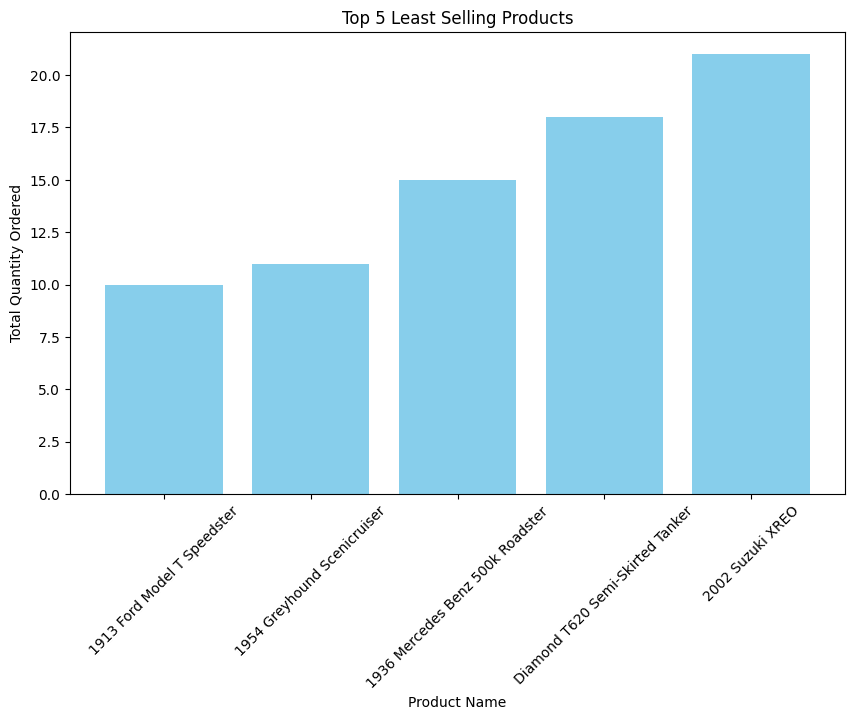

In [10]:
# 가장 안 팔리는 제품 시각화
plt.figure(figsize=(10, 6))
plt.bar(bottom_products_df['productName'], bottom_products_df['total_quantity'], color='skyblue')
plt.xlabel('Product Name')
plt.ylabel('Total Quantity Ordered')
plt.title('Top 5 Least Selling Products')
plt.xticks(rotation=45)
plt.show()

## 가장 많이 (금액) 팔린 제품

In [11]:
# MySQL 데이터베이스 연결 설정
conn = mysql.connector.connect(
    host='localhost',
    user='root',
    password='doruru0614!@#',        # 실제 비밀번호로 변경하세요
    database='classicmodels'
)

In [12]:
# 가장 많이 팔린 제품 분석 쿼리 실행
# 각 제품의 총 매출(total_sales)을 계산하고, 가장 높은 매출을 기록한 상위 5개 제품을 찾는 쿼리
top_products_query = """
SELECT
    od.productCode,
    p.productName,
    SUM(od.quantityOrdered * od.priceEach) AS total_sales
FROM
    orderdetails od
JOIN
    products p ON od.productCode = p.productCode
GROUP BY
    od.productCode
ORDER BY
    total_sales DESC
LIMIT 5;

"""

In [ ]:
# 가장 적게 팔린 제품 분석 쿼리 실행
bottom_products_query = """
SELECT
    od.productCode,
    p.productName,
    SUM(od.quantityOrdered * od.priceEach) AS total_sales
FROM
    orderdetails od
JOIN
    products p ON od.productCode = p.productCode
GROUP BY
    od.productCode
ORDER BY
    total_sales ASC
LIMIT 5;
"""

In [14]:
# SQL 쿼리 실행 및 결과 DataFrame으로 변환
top_products_df = pd.read_sql_query(top_products_query, conn)
bottom_products_df = pd.read_sql_query(bottom_products_query, conn)

In [15]:
# 연결 종료
conn.close()

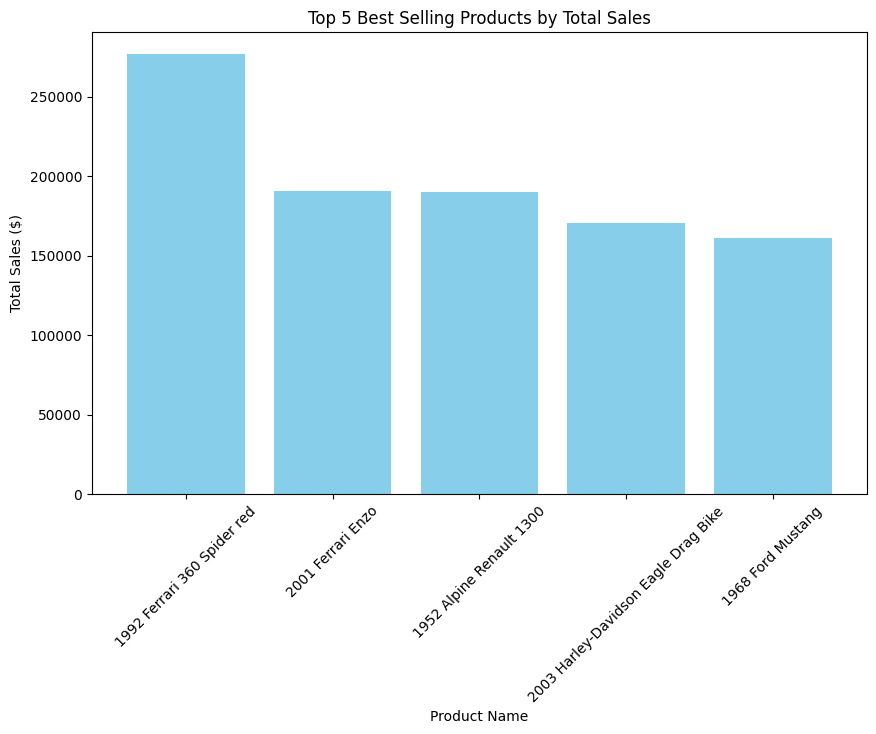

In [16]:
# 가장 많이 팔린 제품 시각화
plt.figure(figsize=(10, 6))
plt.bar(top_products_df['productName'], top_products_df['total_sales'], color='skyblue')
plt.xlabel('Product Name')
plt.ylabel('Total Sales ($)')
plt.title('Top 5 Best Selling Products by Total Sales')
plt.xticks(rotation=45)
plt.show()

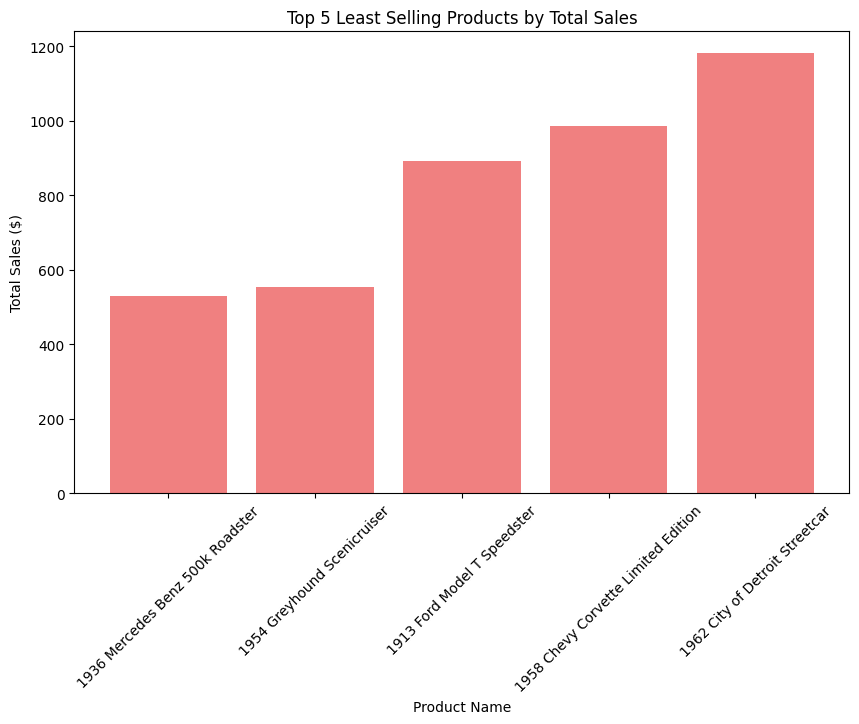

In [17]:
# 가장 적게 팔린 제품 시각화
plt.figure(figsize=(10, 6))
plt.bar(bottom_products_df['productName'], bottom_products_df['total_sales'], color='lightcoral')
plt.xlabel('Product Name')
plt.ylabel('Total Sales ($)')
plt.title('Top 5 Least Selling Products by Total Sales')
plt.xticks(rotation=45)
plt.show()

- 결과를 분석해보면, 수량으로 많이/적게 팔린 제품과 금액으로 많이/적게 팔린 제품이 다르며, 회사의 주력상품의 매출이 잘 나오고 있는지, 마케팅이 잘 되고 있는지 등을 분석하고 향후 방향성을 제시
